# Sine Wave RNN Forecasting

This notebook rebuilds the idea from `RNN(sinewave).ipynb` into a cleaner fundamentals walkthrough.

## Goal

Use a sliding window of past sine-wave values to predict the next value in the sequence.

## Data

The series is synthetic, so the notebook can run anywhere without extra files.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

np.random.seed(7)
print("Libraries ready: numpy, pandas, matplotlib, scikit-learn")

Libraries ready: numpy, pandas, matplotlib, scikit-learn


## Build The Sequence

The original notebook used a sine wave because it is easy to see whether the model learns the repeating shape.


,time,sine
0,0.0,0.000000
1,0.1,0.099833
2,0.2,0.198669
3,0.3,0.295520
4,0.4,0.389418


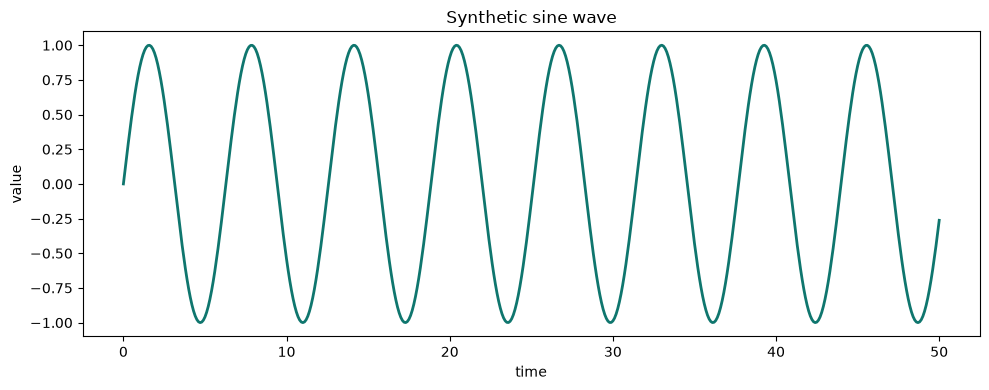

In [2]:
x = np.linspace(0, 50, 501)
y = np.sin(x)
df = pd.DataFrame({"time": x, "sine": y})

display(df.head())

plt.figure(figsize=(10, 4))
plt.plot(df["time"], df["sine"], color="#0f766e", linewidth=2)
plt.title("Synthetic sine wave")
plt.xlabel("time")
plt.ylabel("value")
plt.tight_layout()
plt.show()

## Preprocessing

Time-series splits should stay chronological. I keep the last 10% for testing, scale from the training split only, and then create fixed-length windows.


In [3]:
split_index = int(len(df) * 0.9)
train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[["sine"]])
test_scaled = scaler.transform(test[["sine"]])

window = 30

def make_windows(series, length):
    X, y = [], []
    for start in range(len(series) - length):
        X.append(series[start:start + length])
        y.append(series[start + length])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, window)

print(f"Train points: {len(train)}")
print(f"Test points: {len(test)}")
print(f"Windowed training shape: {X_train.shape}")
print("First five scaled values from the first window:", np.round(X_train[0, :5, 0], 4))

Train points: 450
Test points: 51
Windowed training shape: (420, 30, 1)
First five scaled values from the first window: [0.5    0.5499 0.5993 0.6478 0.6947]


## Model

TensorFlow is not available in this local environment, so I built a very small recurrent network with NumPy. It keeps the same learning idea from the source notebook: a hidden state reads one value at a time, then predicts the next value after the full window.


In [4]:
class TinyRNN:
    def __init__(self, input_dim=1, hidden_dim=12, seed=7):
        rng = np.random.default_rng(seed)
        self.hidden_dim = hidden_dim
        self.Wx = rng.normal(0, 0.3, (input_dim, hidden_dim))
        self.Wh = rng.normal(0, 0.3, (hidden_dim, hidden_dim))
        self.bh = np.zeros((1, hidden_dim))
        self.Wy = rng.normal(0, 0.3, (hidden_dim, 1))
        self.by = np.zeros((1, 1))

    def forward(self, X):
        sample_count, steps, _ = X.shape
        hidden_states = np.zeros((sample_count, steps, self.hidden_dim))
        hidden_prev = np.zeros((sample_count, self.hidden_dim))

        for step in range(steps):
            hidden_prev = np.tanh(X[:, step, :] @ self.Wx + hidden_prev @ self.Wh + self.bh)
            hidden_states[:, step, :] = hidden_prev

        prediction = hidden_states[:, -1, :] @ self.Wy + self.by
        return prediction, hidden_states

    def fit(self, X, y, epochs=350, learning_rate=0.02):
        losses = []
        sample_count, steps, _ = X.shape

        for _ in range(epochs):
            prediction, hidden_states = self.forward(X)
            error = prediction - y
            loss = np.mean(error ** 2)
            losses.append(loss)

            d_prediction = (2.0 / sample_count) * error
            dWy = hidden_states[:, -1, :].T @ d_prediction
            dby = d_prediction.sum(axis=0, keepdims=True)

            d_hidden_next = d_prediction @ self.Wy.T
            dWx = np.zeros_like(self.Wx)
            dWh = np.zeros_like(self.Wh)
            dbh = np.zeros_like(self.bh)

            for step in range(steps - 1, -1, -1):
                hidden_now = hidden_states[:, step, :]
                hidden_prev = hidden_states[:, step - 1, :] if step > 0 else np.zeros((sample_count, self.hidden_dim))
                d_tanh = d_hidden_next * (1 - hidden_now ** 2)
                dWx += X[:, step, :].T @ d_tanh
                dWh += hidden_prev.T @ d_tanh
                dbh += d_tanh.sum(axis=0, keepdims=True)
                d_hidden_next = d_tanh @ self.Wh.T

            for grad in (dWx, dWh, dbh, dWy, dby):
                np.clip(grad, -1.0, 1.0, out=grad)

            self.Wx -= learning_rate * dWx
            self.Wh -= learning_rate * dWh
            self.bh -= learning_rate * dbh
            self.Wy -= learning_rate * dWy
            self.by -= learning_rate * dby

        return np.array(losses)

    def predict(self, X):
        return self.forward(X)[0]

    def forecast(self, seed_window, steps):
        current_window = seed_window.copy().reshape(-1, 1)
        predictions = []

        for _ in range(steps):
            next_value = self.predict(current_window.reshape(1, len(current_window), 1))[0, 0]
            predictions.append(next_value)
            current_window = np.vstack([current_window[1:], [[next_value]]])

        return np.array(predictions).reshape(-1, 1)

print("TinyRNN class ready")

TinyRNN class ready


## Training

The model predicts one step ahead from each training window. Even on a tiny synthetic series, the loss curve is a good quick check that the recurrence is learning something stable.


Final training loss: 0.000368


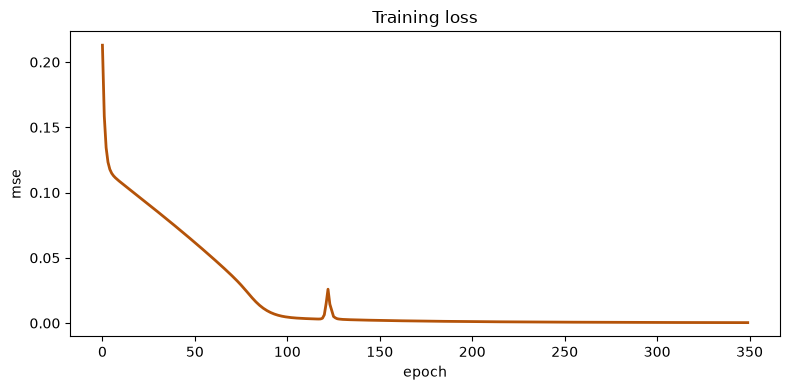

In [5]:
model = TinyRNN(hidden_dim=12, seed=7)
losses = model.fit(X_train, y_train, epochs=350, learning_rate=0.02)

print(f"Final training loss: {losses[-1]:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, color="#b45309", linewidth=2)
plt.title("Training loss")
plt.xlabel("epoch")
plt.ylabel("mse")
plt.tight_layout()
plt.show()

## Evaluation

I compare the recurrent model against a simple baseline that predicts the last value in each window. The test windows are teacher-forced: each window uses real historical values, so this tells us whether the model understands the local sine-wave pattern.


In [6]:
full_scaled = np.vstack([train_scaled, test_scaled])
start = split_index - window

X_test, y_test = make_windows(full_scaled[start:], window)
y_test = y_test[: len(test)]
X_test = X_test[: len(test)]

baseline_scaled = X_test[:, -1, :]
rnn_scaled = model.predict(X_test)

baseline_pred = scaler.inverse_transform(baseline_scaled)
rnn_pred = scaler.inverse_transform(rnn_scaled)
actual = scaler.inverse_transform(y_test)

metrics = pd.DataFrame(
    {
        "model": ["Last value baseline", "Tiny NumPy RNN"],
        "mae": [
            mean_absolute_error(actual, baseline_pred),
            mean_absolute_error(actual, rnn_pred),
        ],
        "rmse": [
            mean_squared_error(actual, baseline_pred) ** 0.5,
            mean_squared_error(actual, rnn_pred) ** 0.5,
        ],
    }
)

display(metrics.round(4))

,model,mae,rmse
0,Last value baseline,0.0577,0.0654
1,Tiny NumPy RNN,0.0375,0.0419


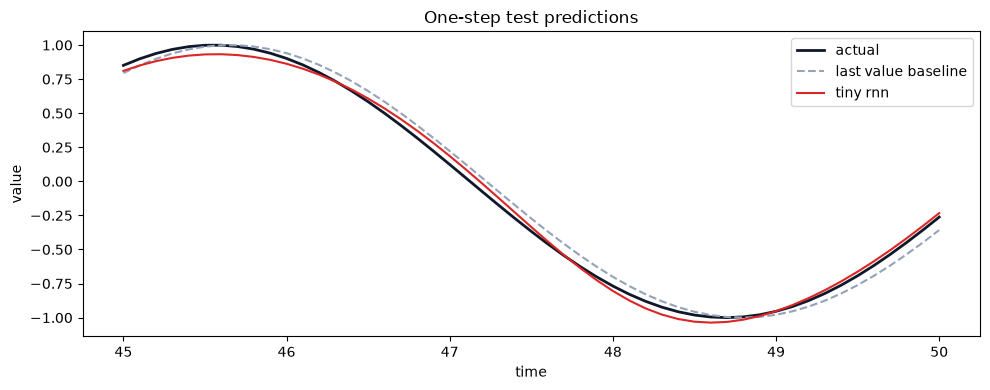

In [7]:
comparison = test.copy()
comparison["baseline"] = baseline_pred
comparison["rnn_prediction"] = rnn_pred

plt.figure(figsize=(10, 4))
plt.plot(comparison["time"], comparison["sine"], label="actual", linewidth=2, color="#0f172a")
plt.plot(comparison["time"], comparison["baseline"], label="last value baseline", linestyle="--", color="#94a3b8")
plt.plot(comparison["time"], comparison["rnn_prediction"], label="tiny rnn", color="#dc2626")
plt.title("One-step test predictions")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

## Recursive Forecast And Limits

The harder test is recursive forecasting: after the first step, the model must consume its own predictions instead of the real series. This is where small sequence models can drift away from the wave.


Recursive MAE: 0.2404
Recursive RMSE: 0.2740


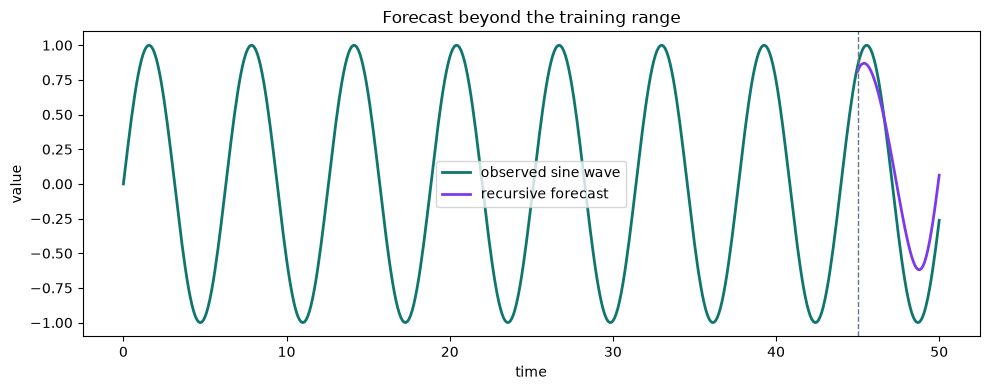

In [8]:
forecast_scaled = model.forecast(train_scaled[-window:], len(test_scaled))
forecast = scaler.inverse_transform(forecast_scaled)

recursive_mae = mean_absolute_error(test[["sine"]], forecast)
recursive_rmse = mean_squared_error(test[["sine"]], forecast) ** 0.5

print(f"Recursive MAE: {recursive_mae:.4f}")
print(f"Recursive RMSE: {recursive_rmse:.4f}")

forecast_frame = pd.DataFrame(
    {
        "time": test["time"].to_numpy(),
        "forecast": forecast.ravel(),
    }
)

plt.figure(figsize=(10, 4))
plt.plot(df["time"], df["sine"], label="observed sine wave", color="#0f766e", linewidth=2)
plt.plot(forecast_frame["time"], forecast_frame["forecast"], label="recursive forecast", color="#7c3aed", linewidth=2)
plt.axvline(test["time"].iloc[0], color="#64748b", linestyle="--", linewidth=1)
plt.title("Forecast beyond the training range")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

## What I Learned

- A recurrent model can beat a plain last-value baseline on one-step predictions when the pattern is smooth and repeated.
- Recursive forecasting is harder because small errors compound once the model starts feeding on its own outputs.
- Sequence window length matters: it controls how much history the recurrent state can use before making the next prediction.
